#  Medical Insurance Cost Prediction
## Notebook 4 — Model Comparison & SHAP Analysis

---
**Input :** `data/processed/model_results.csv` + `models/*.pkl`  
**Goal  :** Compare all models, interpret the best one with SHAP, and draw final conclusions.



<a id='1'></a>
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

os.makedirs('../reports/figures', exist_ok=True)


<a id='2'></a>
## 2. Load Results & Models

In [3]:
# Results table
results_df = pd.read_csv('/content/model_results.csv')

# Test data
X_test = pd.read_csv('/content/X_test.csv')
X_test_scaled = pd.read_csv('/content/X_test_scaled.csv')
y_test  = pd.read_csv('/content/y_test.csv').squeeze()
y_test_raw  = pd.read_csv('/content/y_test_raw.csv').squeeze()

X_train     = pd.read_csv('/content/X_train.csv')
y_train     = pd.read_csv('/content/y_train.csv').squeeze()

# NaN fill
X_test = X_test.fillna(X_test.median())
X_test_scaled = X_test_scaled.fillna(X_test_scaled.median())
X_train  = X_train.fillna(X_train.median())

# Models
models = {
    'Linear Regression' : joblib.load('/content/models/linear_regression.pkl'),
    'Ridge'             : joblib.load('/content/models/ridge.pkl'),
    'Lasso'             : joblib.load('/content/models/lasso.pkl'),
    'Decision Tree'     : joblib.load('/content/models/decision_tree.pkl'),
    'Random Forest'     : joblib.load('/content/models/random_forest.pkl'),
    'Gradient Boosting' : joblib.load('/content/models/gradient_boosting.pkl'),
    'XGBoost'           : joblib.load('/content/models/xgboost.pkl'),
    'LightGBM'          : joblib.load('/content/models/lightgbm.pkl'),
}

best_model = joblib.load('/content/models/best_model.pkl')

# Linear models use scaled data
linear_models = ['Linear Regression', 'Ridge', 'Lasso']

print(' All models and data loaded.')
print(f'Best model: {results_df.iloc[0]["Model"]}')

 All models and data loaded.
Best model: Gradient Boosting


<a id='3'></a>
## 3. Model Comparison

In [15]:
# Styled results table
display(
    results_df.sort_values('R2', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(subset=['R2', 'CV R2 Mean'], cmap='Greens')
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE (%)'], cmap='Reds_r')
    .format({'R2': '{:.4f}', 'CV R2 Mean': '{:.4f}',
             'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'MAPE (%)': '{:.2f}'})
)

,Model,R2,RMSE,MAE,MAPE (%),CV R2 Mean,CV R2 Std,Fit Time(s)
0,Gradient Boosting,0.0636,"3,018.94","1,693.37",74.68,0.1811,0.003300,28.400000
1,XGBoost,0.0634,"3,019.27","1,693.53",74.71,0.1811,0.003000,0.700000
2,LightGBM,0.0608,"3,023.43","1,694.68",74.77,0.1805,0.003200,0.400000
3,Random Forest,0.0586,"3,027.00","1,695.84",74.84,0.1786,0.003200,17.700000
4,Ridge Regression,0.0582,"3,027.64","1,701.04",75.11,0.1751,0.003000,0.000000
5,Linear Regression,0.0582,"3,027.59","1,701.04",75.11,0.1751,0.003000,0.000000
6,Lasso Regression,0.0578,"3,028.17","1,701.02",75.10,0.1751,0.003000,0.100000
7,Decision Tree,0.0545,"3,033.52","1,705.26",75.37,0.1695,0.004400,0.200000


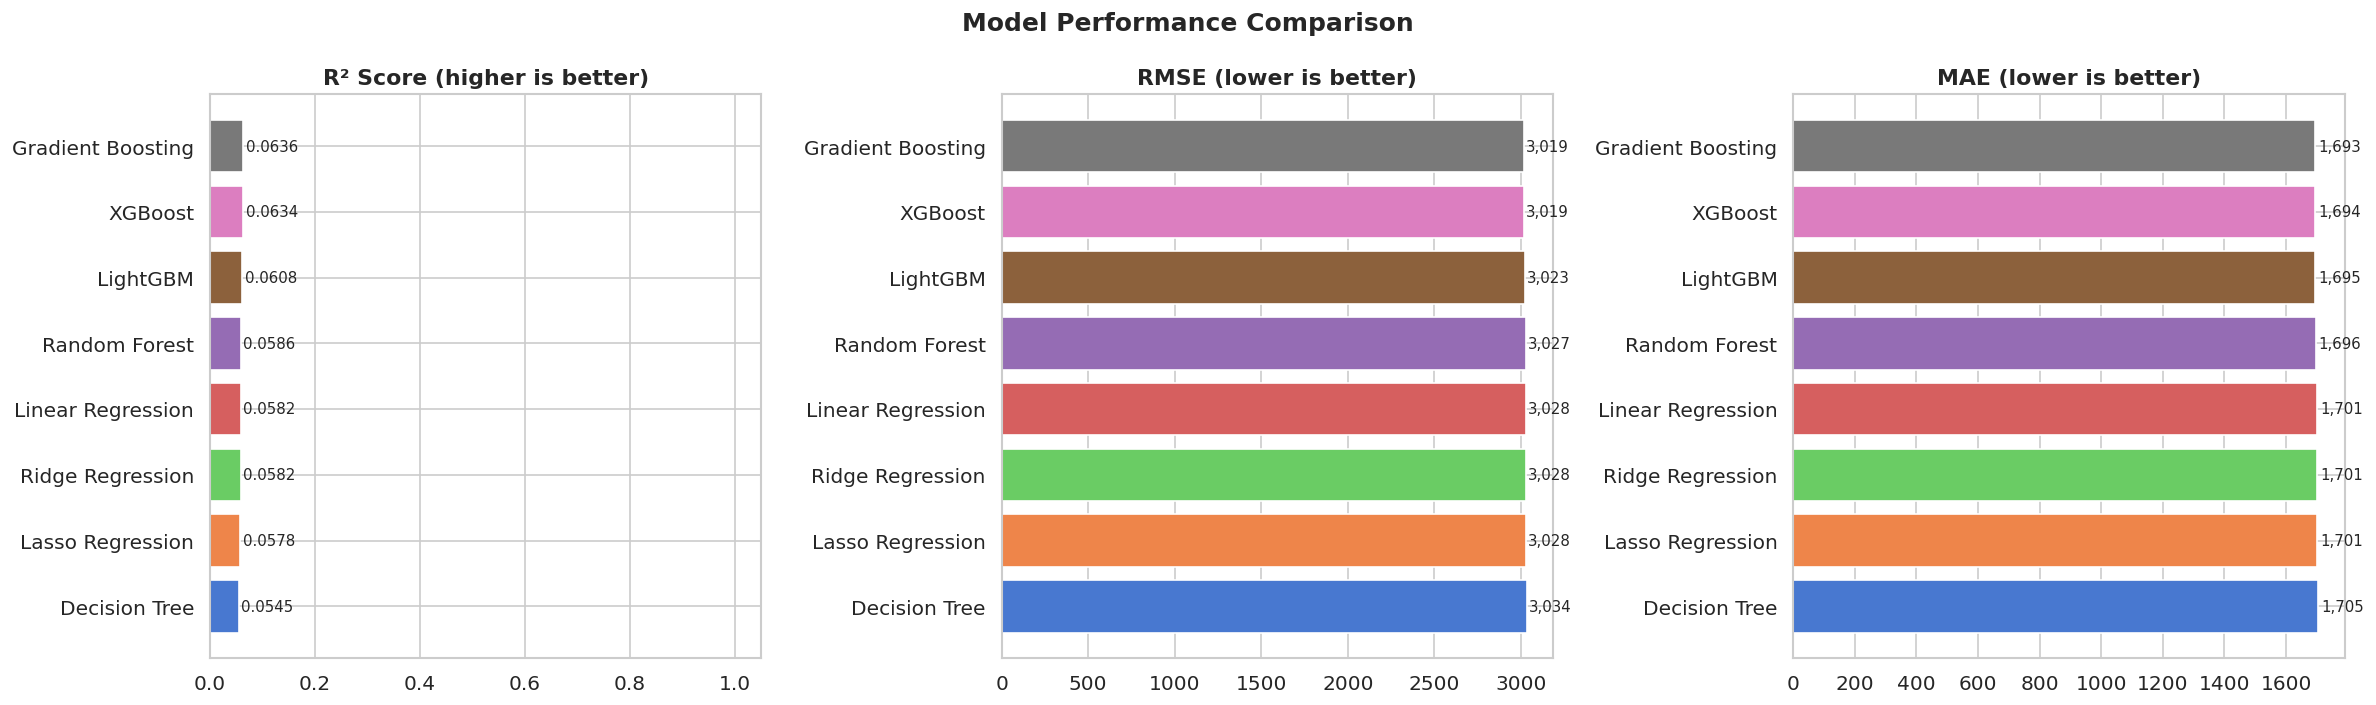

In [16]:
# Grouped bar chart — R2, RMSE, MAE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df_plot = results_df.sort_values('R2', ascending=True)
palette = sns.color_palette('muted', len(df_plot))

# R2
bars = axes[0].barh(df_plot['Model'], df_plot['R2'], color=palette)
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, df_plot['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars = axes[1].barh(df_plot['Model'], df_plot['RMSE'], color=palette)
axes[1].set_title('RMSE (lower is better)')
for bar, val in zip(bars, df_plot['RMSE']):
    axes[1].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

# MAE
bars = axes[2].barh(df_plot['Model'], df_plot['MAE'], color=palette)
axes[2].set_title('MAE (lower is better)')
for bar, val in zip(bars, df_plot['MAE']):
    axes[2].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_full.png', bbox_inches='tight')
plt.show()

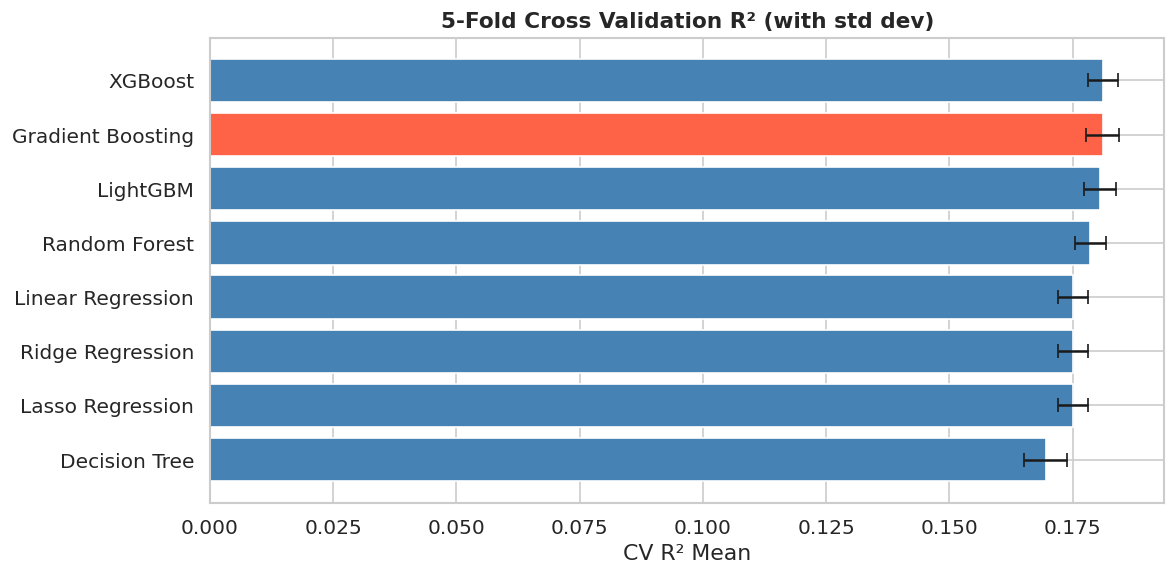

In [17]:
# CV R2 comparison with error bars
fig, ax = plt.subplots(figsize=(10, 5))

df_cv = results_df.sort_values('CV R2 Mean', ascending=True)
colors = ['tomato' if m == results_df.iloc[0]['Model'] else 'steelblue'
          for m in df_cv['Model']]

ax.barh(df_cv['Model'], df_cv['CV R2 Mean'],
        xerr=df_cv['CV R2 Std'],
        color=colors, edgecolor='white', capsize=4)
ax.set_title('5-Fold Cross Validation R² (with std dev)', fontsize=13, fontweight='bold')
ax.set_xlabel('CV R² Mean')

plt.tight_layout()
plt.savefig('../reports/figures/cv_comparison.png', bbox_inches='tight')
plt.show()

<a id='4'></a>
## 4. Residual Analysis

> Residuals = Actual − Predicted. A well-performing model should have residuals  
> centered around zero with no systematic pattern.

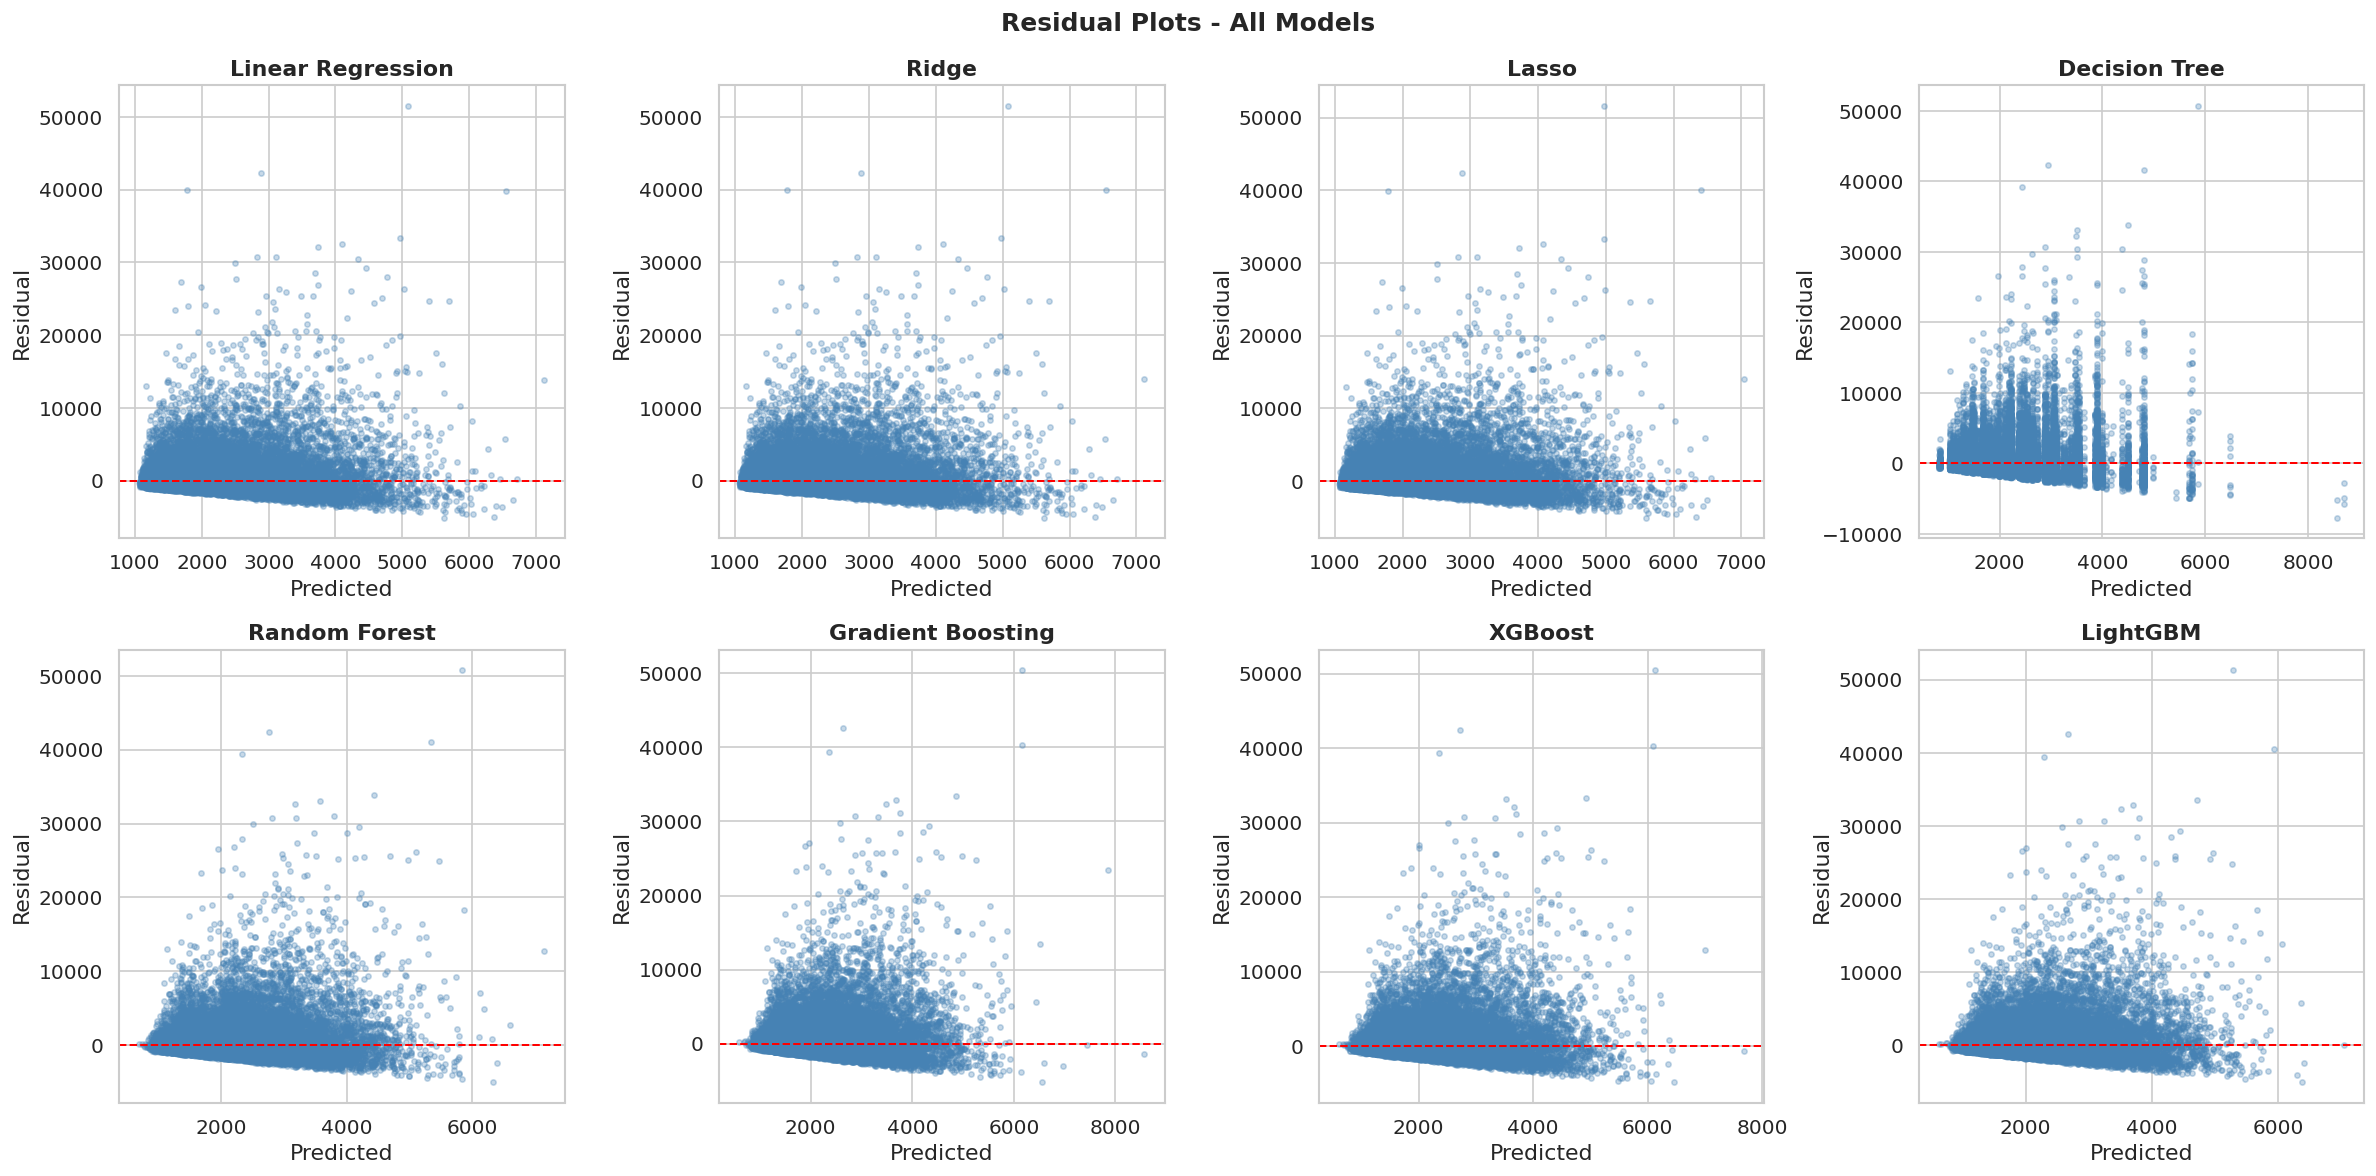

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    X_input = X_test_scaled if name in linear_models else X_test
    y_pred  = np.expm1(model.predict(X_input))
    residuals = y_test_raw.values - y_pred

    axes[i].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')

plt.suptitle('Residual Plots - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/residual_plots.png', bbox_inches='tight')
plt.show()

<a id='5'></a>
## 5. Actual vs Predicted

> A perfect model would have all points on the diagonal line.

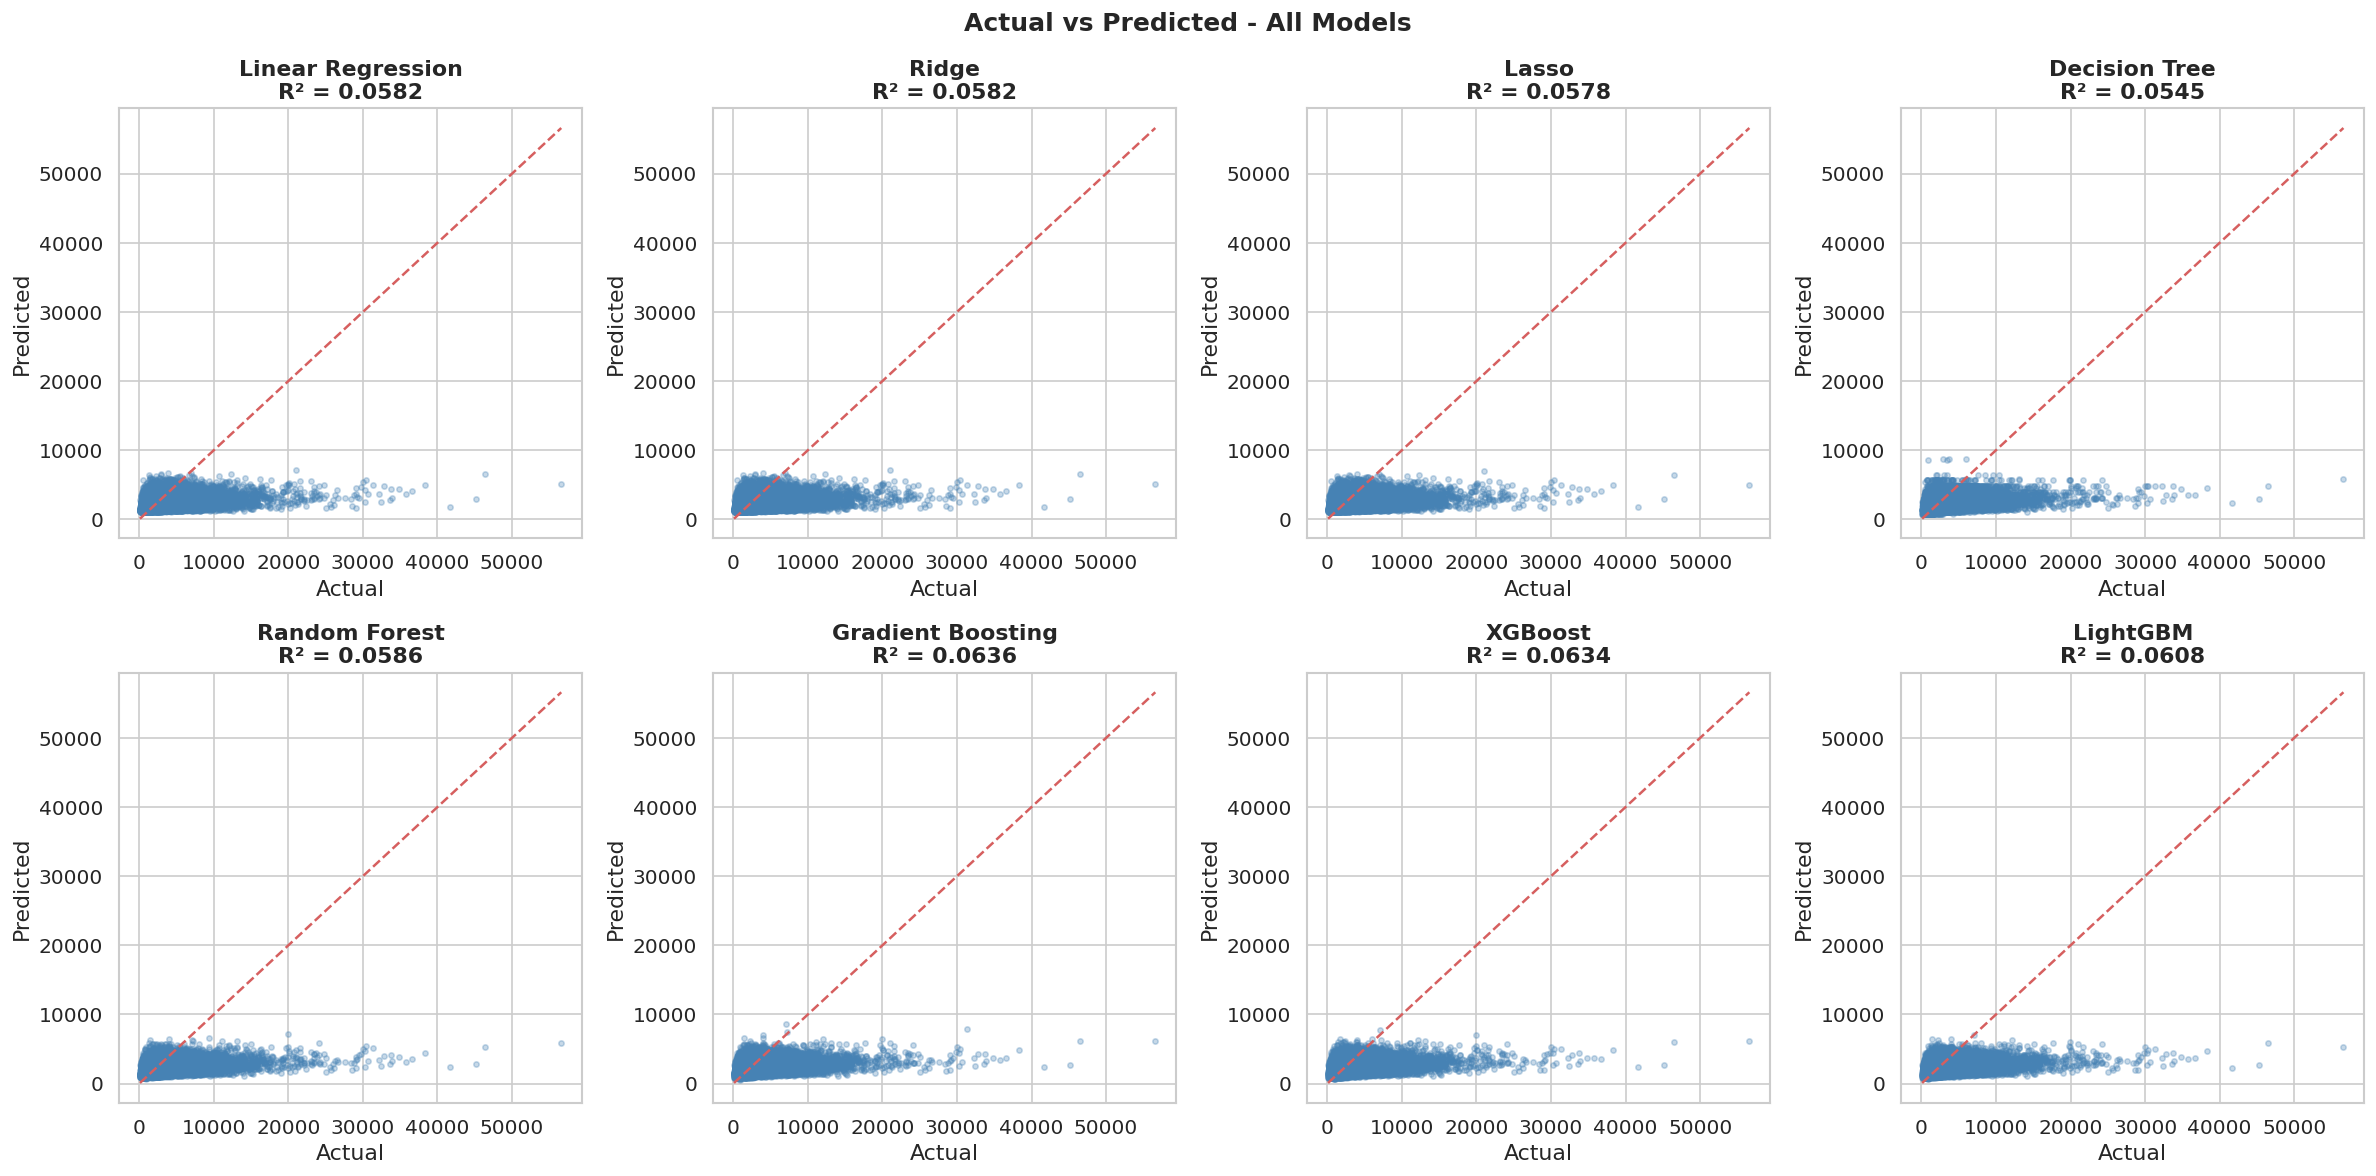

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    X_input = X_test_scaled if name in linear_models else X_test
    y_pred  = np.expm1(model.predict(X_input))
    y_true  = y_test_raw.values

    r2 = r2_score(y_true, y_pred)

    axes[i].scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    axes[i].set_title(f'{name}\nR² = {r2:.4f}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png', bbox_inches='tight')
plt.show()

<a id='6'></a>
## 6. SHAP Analysis

> SHAP (SHapley Additive exPlanations) explains **why** the best model made each prediction.  
> It assigns each feature a contribution value for every individual prediction.

In [20]:
best_model_name = results_df.iloc[0]['Model']
print(f'Running SHAP for: {best_model_name}')

# Use a sample for speed (SHAP can be slow on 100k rows)
X_shap = X_train.sample(n=min(2000, len(X_train)), random_state=42)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

print(' SHAP values computed.')

Running SHAP for: Gradient Boosting
 SHAP values computed.


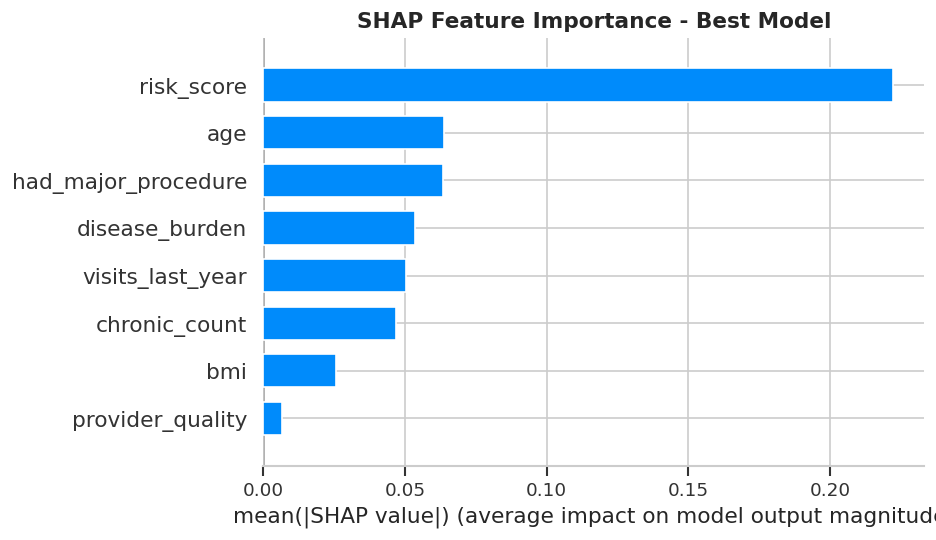

In [22]:
# Summary plot - feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance - Best Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance.png', bbox_inches='tight')
plt.show()

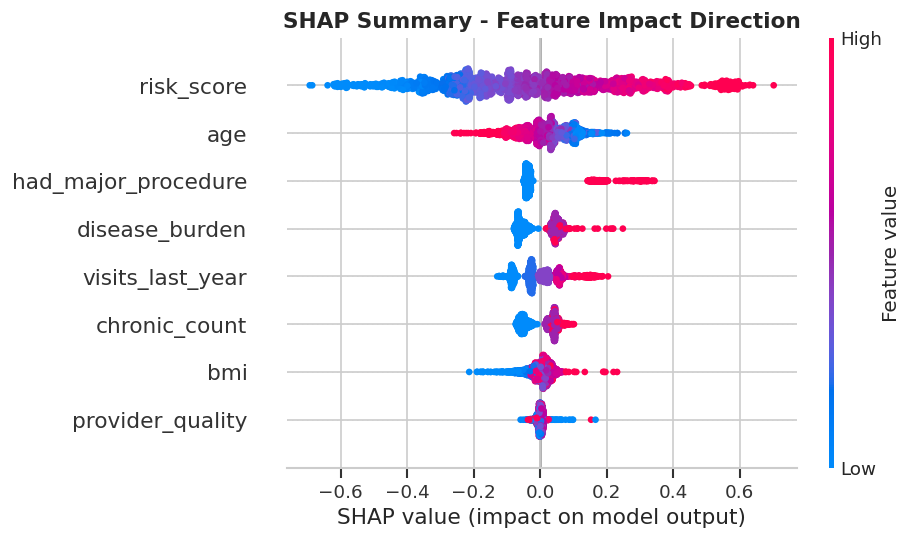

In [23]:
# Beeswarm plot - feature impact direction
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Summary - Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', bbox_inches='tight')
plt.show()

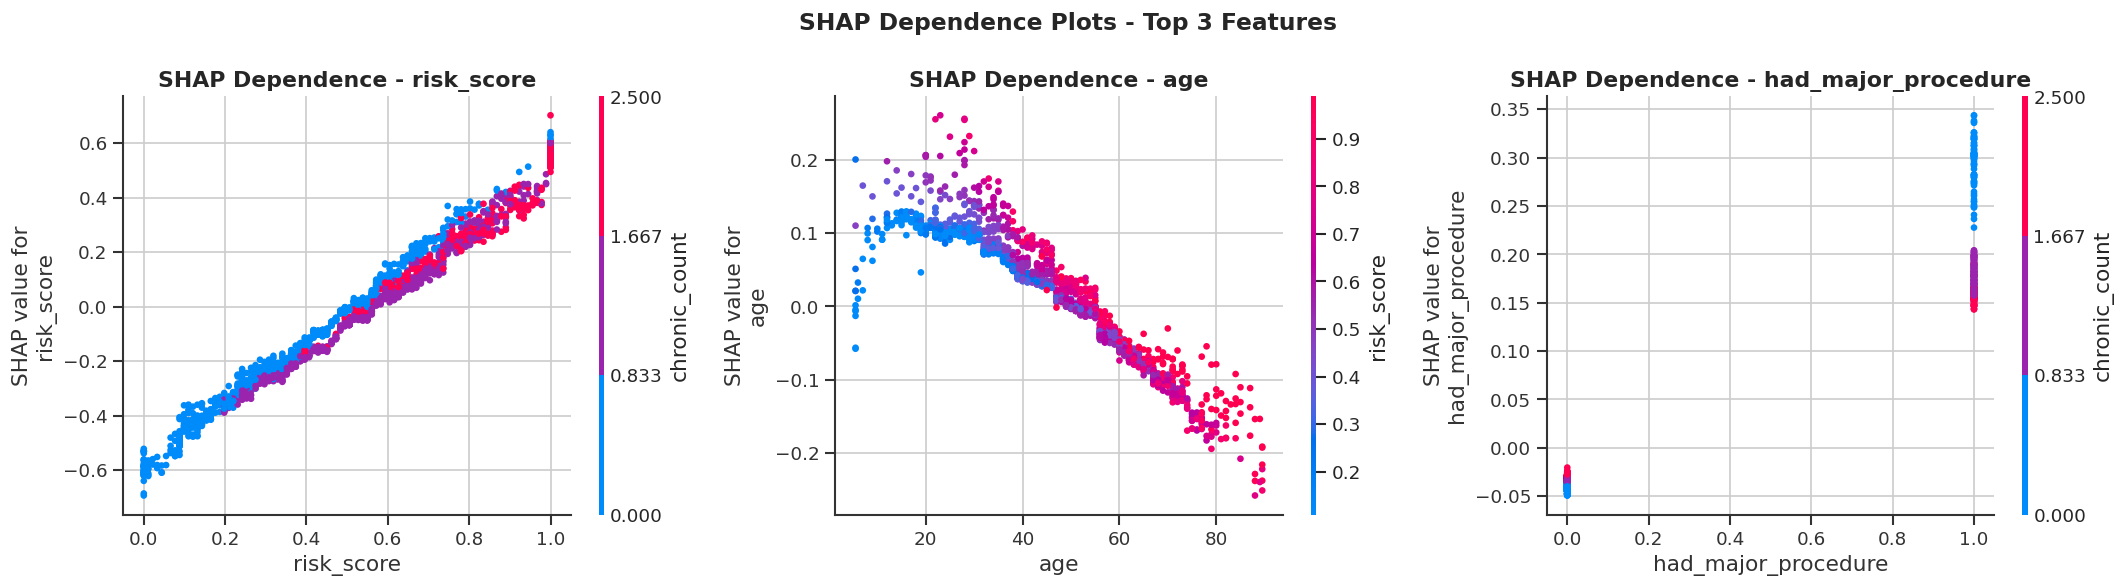

In [24]:
# Dependence plots - top 3 features
feature_names = X_shap.columns.tolist()
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_features = [feature_names[i] for i in np.argsort(mean_abs_shap)[::-1][:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence - {feat}')

plt.suptitle('SHAP Dependence Plots - Top 3 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence.png', bbox_inches='tight')
plt.show()

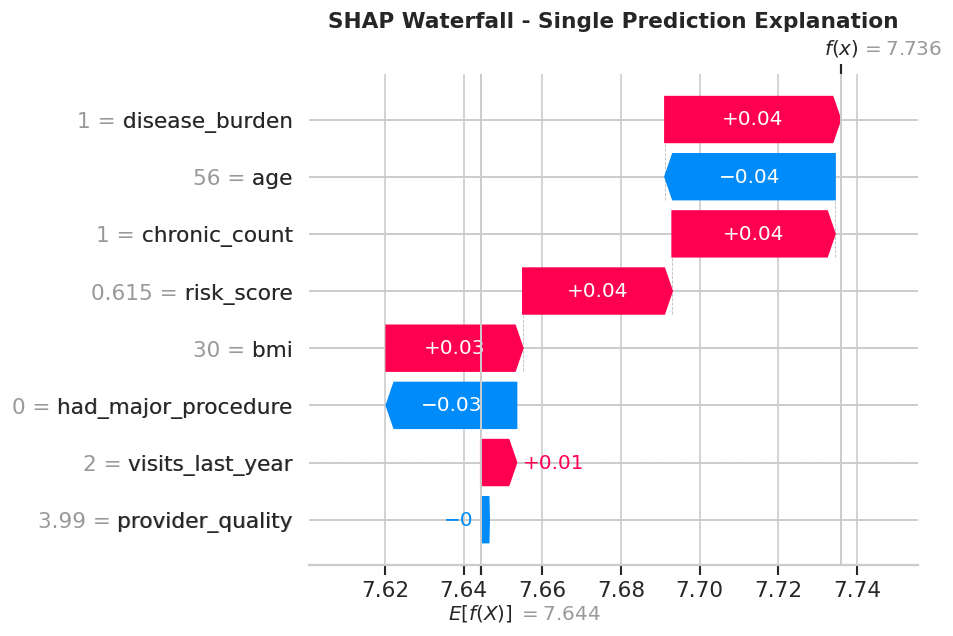

In [25]:
# Waterfall plot - single prediction explanation
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_shap.iloc[0].values,
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall - Single Prediction Explanation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall.png', bbox_inches='tight')
plt.show()

<a id='7'></a>
## 7. Final Conclusions

In [26]:
best = results_df.sort_values('R2', ascending=False).iloc[0]
worst = results_df.sort_values('R2', ascending=False).iloc[-1]

print('=' * 55)
print('         FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'  Best model  : {best["Model"]}')
print(f'  R²          : {best["R2"]:.4f}')
print(f'  RMSE        : {best["RMSE"]:,.2f}')
print(f'  MAE         : {best["MAE"]:,.2f}')
print(f'  MAPE        : {best["MAPE (%)"]:.2f}%')
print(f'  CV R²       : {best["CV R2 Mean"]:.4f} ± {best["CV R2 Std"]:.4f}')
print('-' * 55)
print(f'  Baseline    : {worst["Model"]} (R² = {worst["R2"]:.4f})')
print(f'  Improvement : +{best["R2"] - worst["R2"]:.4f} R²')
print('=' * 55)

         FINAL MODEL COMPARISON SUMMARY
  Best model  : Gradient Boosting
  R²          : 0.0636
  RMSE        : 3,018.94
  MAE         : 1,693.37
  MAPE        : 74.68%
  CV R²       : 0.1811 ± 0.0033
-------------------------------------------------------
  Baseline    : Decision Tree (R² = 0.0545)
  Improvement : +0.0091 R²


In [27]:
# Top SHAP features summary
shap_importance = pd.DataFrame({
    'Feature'  : feature_names,
    'Mean |SHAP|' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('\nTop 8 Most Influential Features (SHAP):')
display(shap_importance.head(8))


Top 8 Most Influential Features (SHAP):


,Feature,Mean |SHAP|
0,risk_score,0.222280
1,age,0.063712
2,had_major_procedure,0.063604
3,disease_burden,0.053643
4,visits_last_year,0.050382
5,chronic_count,0.046902
6,bmi,0.025811
7,provider_quality,0.006589
